<h3 style="background-color:#1E3A8A; color:white; padding:15px; border-radius:8px; font-family:Helvetica; text-align:center;">
    🚀 Model comparison & Selection
</h3>


#### Phase 7.1 : Productionn Model Preparation 
##### The model development and evaluation process has been completed in the previous notebook. in this notebook we prepare the selected model for production use. 
- Organizing production artifacts
- Saving the final trained model
- Saving model metadata
- Building a reusable prediction pipeline
- Preparing outputs for the dashboard and web application

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import * 

In [4]:
%store -r X_train
%store -r X_test
%store -r y_train
%store -r y_test
%store -r best_rf
%store -r comparison
%store -r important
%store -r final_feature

df = pd.DataFrame(X_test)
df.to_csv('sample.csv',index=False)

### Phase 7.2 : Veritfy Production artifacts
#### Before preparing the production pipeline we will check the following objects :
- Final trained Model
- training features
- Target Variable
- train/test datasets
- predictionn threshold 
- features names

In [4]:
req_obj = ['best_rf','X_train','X_test','y_train','y_test']
for obj in req_obj :
    if obj in globals():
        print(f'{obj:<15} Available')
    else :
        print(f'{obj:<15} Not available')

print('Final Model information')
print(best_rf)

best_rf         Available
X_train         Available
X_test          Available
y_train         Available
y_test          Available
Final Model information
RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)


In [5]:
print("Training shape : ",X_train.shape)
print("Testing shape : ",X_test.shape)
print()
print("Number of features : ",X_train.shape[1])
print("Features Name\n",pd.Series(X_train.columns))

Training shape :  (32924, 8)
Testing shape :  (8232, 8)

Number of features :  8
Features Name
 0                  std_cons
1                zero_ratio
2           high_cons_ratio
3                       PAR
4                        cv
5                 Stability
6    longest_missing_streak
7       longest_zero_streak
dtype: object


In [6]:
print("best Threshold : ",0.25)

best Threshold :  0.25


### Phase 7.3 : Save Final Model 
##### The following files will be saved:
- Final Random Forest Model
- Feature List
- Decision Threshold
- Model Comparison Table

In [7]:
import os 
import joblib

In [11]:
model_path=r"C:\Users\vinee\ML_Project\models"
def saving_model(save,name):
    joblib.dump(save,
    os.path.join(model_path,f'{name}.pkl'))
    print('saved')

In [ ]:
saving_model(best_rf,'best_random_forest')
saving_model(final_feature,'feature_names')
saving_model(0.25,'threshold')
comparison.to_csv(
    os.path.join(model_path,'model_comparisonn.csv'),index=False
)

saved
saved
saved


In [17]:
# reload verification 
def verification(file_name):
    check = joblib.load(
        os.path.join(model_path,f'{file_name}.pkl'))
    if 'random_forest' in file_name :
        return print(type(check))
    else :
        return print(check)

In [ ]:
verification('best_random_forest')
verification('feature_names')
verification('threshold')


<class 'sklearn.ensemble._forest.RandomForestClassifier'>
['std_cons', 'zero_ratio', 'high_cons_ratio', 'PAR', 'cv', 'Stability', 'longest_missing_streak', 'longest_zero_streak']
0.25


### Phase 7.4 : Build Production Prediction Pipeline 
#### The objective of this phase is to create a reusable prediction pipeline using the saved production model.
- Accepts new customer data
- Selects the required features
- Predicts fraud probability
- Applies the optimized threshold
- Returns prediction label and probability



In [21]:
def artifact(name):
    return joblib.load(
        os.path.join(model_path,f'{name}.pkl')
    )

In [26]:
model=artifact('best_random_forest')
feature_names = artifact("feature_names")
threshold = artifact("threshold")
print("artifacts loaded successfully")

artifacts loaded successfully


##### Prediction Function

In [90]:
def predict_customer(data_input):
    data = data_input.copy()
    data = data[feature_names]
    probability = model.predict_proba(data)[:,1]
    prediction = (probability >= threshold).astype(int)
    result = data.copy()
    result['Fraud_Probability'] = probability
    result['Prediction']=prediction
    result['Prediction_label'] = np.where(prediction==1,'Fraud','Normal')
    return result

In [91]:
sample = X_test.head(10)
predict_customer(sample)

,std_cons,zero_ratio,high_cons_ratio,PAR,cv,Stability,longest_missing_streak,longest_zero_streak,Fraud_Probability,Prediction,Prediction_label
28396,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,108,758,0.131320,0,Normal
29918,4.472216,0.000000,0.427365,3.423511,0.326012,0.754141,332,0,0.375415,1,Fraud
2515,0.041413,0.966118,0.033882,44.913043,0.041138,0.960487,1,205,0.089012,0,Normal
14753,3.087737,0.000000,0.347953,2.728198,0.365493,0.732336,2,0,0.295127,1,Fraud
12853,2.104582,0.000973,0.435798,2.646589,0.306943,0.765144,3,1,0.224965,0,Normal
32493,6.529597,0.425558,0.440447,6.229773,1.027745,0.493159,222,78,0.654241,1,Fraud
32680,0.352662,0.957237,0.029605,151.456172,0.340152,0.746184,730,96,0.253768,1,Fraud
26938,3.280063,0.003367,0.494949,3.280762,0.578841,0.633376,730,1,0.584073,1,Fraud
33642,2.678167,0.000000,0.526490,2.039925,0.320615,0.757223,730,0,0.417212,1,Fraud
34514,1.903311,0.148026,0.621711,2.598206,0.470156,0.680200,730,28,0.543152,1,Fraud


In [92]:
prediction_df = predict_customer(X_test)
prediction_df.head()

,std_cons,zero_ratio,high_cons_ratio,PAR,cv,Stability,longest_missing_streak,longest_zero_streak,Fraud_Probability,Prediction,Prediction_label
28396,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,108,758,0.131320,0,Normal
29918,4.472216,0.000000,0.427365,3.423511,0.326012,0.754141,332,0,0.375415,1,Fraud
2515,0.041413,0.966118,0.033882,44.913043,0.041138,0.960487,1,205,0.089012,0,Normal
14753,3.087737,0.000000,0.347953,2.728198,0.365493,0.732336,2,0,0.295127,1,Fraud
12853,2.104582,0.000973,0.435798,2.646589,0.306943,0.765144,3,1,0.224965,0,Normal


In [93]:
print(prediction_df['Prediction_label'].value_counts())
prediction_df['Fraud_Probability'].describe()

Prediction_label
Fraud     6719
Normal    1513
Name: count, dtype: int64


count    8232.000000
mean        0.431583
std         0.171258
min         0.063478
25%         0.296434
50%         0.439332
75%         0.555331
max         0.810647
Name: Fraud_Probability, dtype: float64

In [94]:
# export prediction result
prediction_df.to_csv(
    r"C:\Users\vinee\ML_Project\reports\final_predictions.csv",
    index=False
)

#### Phase 7.4 : Summary
##### Pipeline Capabilities
- Loads production model
- Loads feature list automatically
- Loads optimized threshold
- Predicts fraud probability
- Applies classification threshold
- Returns human-readable prediction labels
- Exports prediction results


### Phase 7.5 : Batch Prediction and Production Validation
####  The objective of this phase is to validate predictionn pipelinne on the complete testing dataset to ensure that :
- The saved model predicts correctly
- Feature ordering remains consistent
- The optimized threshold is correctly applied
- Prediction probabilities are generated correctly
- Batch prediction works without errors


In [95]:
batch_predict = predict_customer(X_test)
batch_predict.head()

,std_cons,zero_ratio,high_cons_ratio,PAR,cv,Stability,longest_missing_streak,longest_zero_streak,Fraud_Probability,Prediction,Prediction_label
28396,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,108,758,0.131320,0,Normal
29918,4.472216,0.000000,0.427365,3.423511,0.326012,0.754141,332,0,0.375415,1,Fraud
2515,0.041413,0.966118,0.033882,44.913043,0.041138,0.960487,1,205,0.089012,0,Normal
14753,3.087737,0.000000,0.347953,2.728198,0.365493,0.732336,2,0,0.295127,1,Fraud
12853,2.104582,0.000973,0.435798,2.646589,0.306943,0.765144,3,1,0.224965,0,Normal


In [96]:
(
    batch_predict['Prediction'].value_counts(normalize=True)
    .mul(100).round(2)
)

Prediction
1    81.62
0    18.38
Name: proportion, dtype: float64

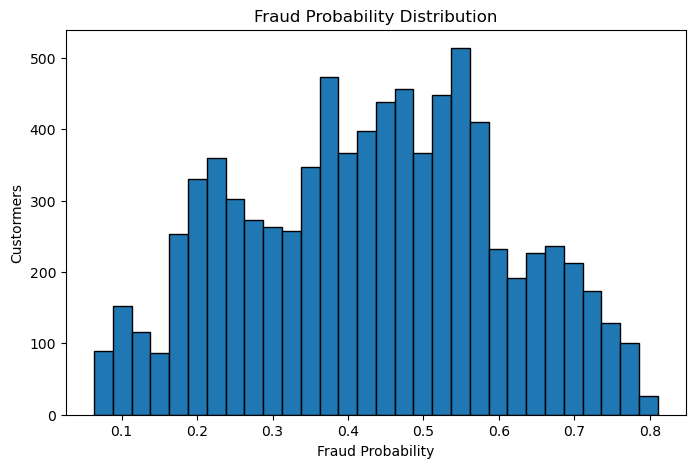

In [97]:
plt.figure(figsize=(8,5))
plt.hist(batch_predict['Fraud_Probability'],bins=30,edgecolor='black')
plt.title('Fraud Probability Distribution')
plt.xlabel("Fraud Probability")
plt.ylabel("Custormers")
plt.show()

In [103]:
high_risk = batch_predict[
    batch_predict['Fraud_Probability']>=0.80
]
print(len(high_risk))
high_risk


6


,std_cons,zero_ratio,high_cons_ratio,PAR,cv,Stability,longest_missing_streak,longest_zero_streak,Fraud_Probability,Prediction,Prediction_label
4045,89.225191,0.162037,0.501157,3.657269,0.874251,0.533547,153,18,0.804989,1,Fraud
41403,116.332747,0.049342,0.565789,2.484427,0.763665,0.567001,730,13,0.800618,1,Fraud
9816,60.526656,0.000000,0.599214,2.666097,0.772378,0.564214,497,0,0.810647,1,Fraud
175,25.101261,0.085470,0.516239,3.734767,0.844458,0.542165,232,50,0.803875,1,Fraud
23388,40.671793,0.000000,0.514212,2.067289,0.709915,0.584825,647,0,0.806237,1,Fraud
24677,236.949468,0.000000,0.460474,4.682179,0.892276,0.528464,465,0,0.802288,1,Fraud


In [107]:
batch_predict.sort_values(
    'Fraud_Probability',ascending=False
).head(10)

,std_cons,zero_ratio,high_cons_ratio,PAR,cv,Stability,longest_missing_streak,longest_zero_streak,Fraud_Probability,Prediction,Prediction_label
9816,60.526656,0.000000,0.599214,2.666097,0.772378,0.564214,497,0,0.810647,1,Fraud
23388,40.671793,0.000000,0.514212,2.067289,0.709915,0.584825,647,0,0.806237,1,Fraud
4045,89.225191,0.162037,0.501157,3.657269,0.874251,0.533547,153,18,0.804989,1,Fraud
175,25.101261,0.085470,0.516239,3.734767,0.844458,0.542165,232,50,0.803875,1,Fraud
24677,236.949468,0.000000,0.460474,4.682179,0.892276,0.528464,465,0,0.802288,1,Fraud
41403,116.332747,0.049342,0.565789,2.484427,0.763665,0.567001,730,13,0.800618,1,Fraud
25792,144.912679,0.312127,0.562624,4.437135,0.869741,0.534833,466,59,0.799976,1,Fraud
15981,26.383809,0.007018,0.496491,2.685871,0.798409,0.556047,459,2,0.799134,1,Fraud
39683,42.150805,0.000000,0.487421,3.944521,0.642558,0.608807,223,0,0.797994,1,Fraud
31452,24.983689,0.000000,0.513158,4.232317,0.738285,0.575280,730,0,0.797946,1,Fraud


In [110]:
batch_predict.to_csv(
    r"C:\Users\vinee\ML_Project\reports\batch_prediction.csv",
    index=False
)

In [113]:
# Validation 
validation = batch_predict.copy()
validation['Actual'] = y_test.values
validation.head()

,std_cons,zero_ratio,high_cons_ratio,PAR,cv,Stability,longest_missing_streak,longest_zero_streak,Fraud_Probability,Prediction,Prediction_label,Actual
28396,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,108,758,0.131320,0,Normal,0
29918,4.472216,0.000000,0.427365,3.423511,0.326012,0.754141,332,0,0.375415,1,Fraud,0
2515,0.041413,0.966118,0.033882,44.913043,0.041138,0.960487,1,205,0.089012,0,Normal,0
14753,3.087737,0.000000,0.347953,2.728198,0.365493,0.732336,2,0,0.295127,1,Fraud,0
12853,2.104582,0.000973,0.435798,2.646589,0.306943,0.765144,3,1,0.224965,0,Normal,0


In [115]:
cm = confusion_matrix(
    validation['Actual'],validation['Prediction']
)

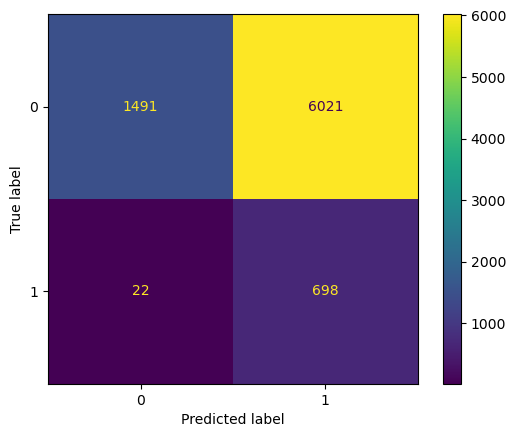

In [117]:
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [118]:
print(classification_report(
    validation['Actual'],validation['Prediction']
))

              precision    recall  f1-score   support

           0       0.99      0.20      0.33      7512
           1       0.10      0.97      0.19       720

    accuracy                           0.27      8232
   macro avg       0.54      0.58      0.26      8232
weighted avg       0.91      0.27      0.32      8232



#### Phase 7.5 : Summary
##### Validation Results
- Batch prediction executed successfully.
- No missing values were produced.
- Fraud probabilities were generated correctly.
- Predictions matched the optimized threshold.
- High-risk customers were identified.
- Prediction results were exported successfully.
- Model remained stable during batch inference.


### Phase 7.6 Production Package Preparation
#### the objective is to prepare the machine learning project for deployment.

In [120]:
deployment_info = {
    'model':'Random Forest',
    'version': '1.0',
    'threshold':threshold,
    'Features':len(feature_names),
    'status':'production ready'
}
deployment_info

{'model': 'Random Forest',
 'version': '1.0',
 'threshold': 0.25,
 'Features': 8,
 'status': 'production ready'}

In [121]:
import json
with open(f'{model_path}/model_metadata.json','w') as f :
    json.dump(deployment_info,f,indent=4)

### Phase 7.6 : summary 
#### the prodcution package has been successfully prepared.
#### completed components :
- Trained Random Forest Model
- Saved Production Model
- Saved Feature Names
- Saved Decision Threshold
- Prediction Pipeline
- Batch Prediction Validation
- Deployment Metadata


## The machine learing model is now fully packaged for deployment.